# **Exploring Missing Data Imputation Methods for VM Data**
### 📌 Notebook Aim
This notebook investigates the **quality** of different methods for imputing missing values in VM (Virtual Machine) data. We explore both simple statistical approaches and advanced machine learning-based techniques to handle **single-record** missing values as well as **missing gaps** within the data. The goal is to determine the method that **minimizes distortion** while preserving the original data distribution.

### 🛠 **Imputation Methods Explored**
1. **Statistical Methods (Pandas)**
   - 📊 **Median Imputation**: `df['column'].median()`
   - 📈 **Linear Interpolation**: `df['column'].interpolate(method='linear')`
   - 🔍 **Nearest Neighbor Interpolation**: `df['column'].interpolate(method='nearest')`
   - 🎢 **Spline Interpolation**: `df['column'].interpolate(method='spline', order=1)`
   - 📐 **Polynomial Interpolation**: `df['column'].interpolate(method='polynomial', order=1)`

2. **Deep Learning-Based Approach**
   - 🤖 **SAITS (Self-Attention-based Imputation for Time Series, 2023)**
     - [GitHub Repository](https://github.com/WenjieDu/SAITS)
     - [Research Paper](https://www.sciencedirect.com/science/article/pii/S0957417423001203?via%3Dihub)


# Hyperparameters for Missing Value Imputation Methods

| Method                          | Hyperparameters                  | Default Values  | Description |
|---------------------------------|--------------------------------|----------------|-------------|
| **fill_nan_with_median**        | None | - | Uses column-wise median to fill NaNs |
| **fill_nan_with_linear**        | None | - | Uses linear interpolation |
| **fill_nan_with_nearest**       | None | - | Uses nearest neighbor interpolation |
| **fill_nan_with_spline**        | `order` | `1` | Uses spline interpolation (order=1 ≈ linear) |
| **fill_nan_with_polynomial**    | `order` | `1` | Uses polynomial interpolation (order=1 ≈ linear) |
| **FillNaNWithDeepLearning**     | `columns` | `[]` | List of columns to impute |
|                                 | `n_steps` | `100` | Number of time steps |
|                                 | `n_features` | `1` | Feature dimension |
|                                 | `n_layers` | `2` | Number of Transformer layers |
|                                 | `d_model` | `256` | Embedding size |
|                                 | `n_heads` | `4` | Attention heads |
|                                 | `d_k, d_v` | `64` | Key/Value dimensions |
|                                 | `d_ffn` | `128` | Feedforward layer size |
|                                 | `dropout` | `0.1` | Dropout probability |
|                                 | `epochs` | `50` | Training epochs |

### ⚠️ **notes**:
For Interpolation Methods:
- `spline` and `polynomial` use `order=1`, which is just linear. Consider `order=2` or 3 for better smoothing.
- For `FillNaNWithDeepLearning`: Consider making `n_steps` dynamic `(min(100, len(X)))` to avoid reshaping issues.


### 📊 **Evaluation Strategy**
- Apply each imputation method to missing values in VM data.
- Compare the effectiveness of each approach based on statistical and visual analysis.
- Identify the method that introduces the least deviation from the original dataset.

### 🚀 **Usage Instructions**
1. Ensure the dataset containing missing values is loaded.
2. Execute each imputation technique and analyze the results.
3. Compare the performance of different approaches and choose the best-suited method.

### ⚠️ **Prerequisites**
- Install required libraries: `pandas`, `numpy`, `matplotlib`, and `SAITS` dependencies if not already available.
- Ensure the dataset is preprocessed correctly before running imputation.
- Ensure to upload VM sample time data:  `vmid___20EFdlSE3atYr9P03_9X4nF16d9RXI+JKVFfvpC281ohXWjFoS9L+ldKyb3ple.csv`.

---

✅ **Author**: _[Mehryar Majd]_  
📅 **Last Updated**: _March 2025_

📌 Necessary considerations should be made regarding the new version of pypots.

### 0. Recover original `vmid` from stored `csv` filenames if you check from `vmtable.csv` in `V1` or `V2` datasets

In [2]:
import re

# Dictionary to store original vmid
vmid_map = {}

def sanitize_filename(vmid):
    sanitized = re.sub(r'[<>:"/\\|?*]', '_', vmid)
    vmid_map[sanitized] = vmid  # Store original vmid
    return sanitized

def unsanitize_filename(sanitized):
    return vmid_map.get(sanitized, None)  # Retrieve original vmid

# Example usage
vmid = "//20EFdlSE3atYr9P03_9X4nF16d9RXI+JKVFfvpC281ohXWjFoS9L+ldKyb3ple"
sanitized = sanitize_filename(vmid)
print("Sanitized VMID to store csv filename:", sanitized)

# Reverse lookup
original_vmid = unsanitize_filename(sanitized)
print("Recovered original VMID:", original_vmid)


Sanitized VMID to store csv filename: __20EFdlSE3atYr9P03_9X4nF16d9RXI+JKVFfvpC281ohXWjFoS9L+ldKyb3ple
Recovered original VMID: //20EFdlSE3atYr9P03_9X4nF16d9RXI+JKVFfvpC281ohXWjFoS9L+ldKyb3ple


### 1. Dependencies

In [ ]:
# !pip install session_info
# !pip install pypots==0.8.1

In [4]:
# Time
# ==============================================================================
import time
import datetime as dt
from datetime import datetime,timedelta


dtime = dt.time()
now = dt.datetime.now()
zeit = now.strftime("%Y-%m-%d %H:%M:%S")
print(f"Last update of notebook: {zeit}" )
#print("Last update of notebook:": format.zeit)

Last update of notebook: 2025-03-17 20:41:57


In [5]:
# # Mount Google Drive
# # ==============================================================================
# from google.colab import drive
# drive.mount("/content/drive", force_remount=True)

In [6]:
import glob
from typing import List

# Data manipulation
# ==============================================================================
import numpy as np
import pandas as pd

# Plots
# ==============================================================================
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Rectangle

# Pre-processing, Modeling and Forecasting and display pipeline , metrics
# ==============================================================================
#from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.base import BaseEstimator, TransformerMixin
from scipy.signal import savgol_filter
from pypots.imputation import SAITS


# Warnings configuration
# ==============================================================================
import warnings
# warnings.filterwarnings('ignore')

2025-03-17 20:42:12 [WARNING]: ‼️ PyPOTS Ecosystem configuration file does not exist.
2025-03-17 20:42:12 [INFO]: Wrote new configs to config.ini successfully.
2025-03-17 20:42:12 [INFO]: 💫 Initialized PyPOTS Ecosystem configuration file /root/.pypots/config.ini successfully.



████████╗██╗███╗   ███╗███████╗    ███████╗███████╗██████╗ ██╗███████╗███████╗    █████╗ ██╗
╚══██╔══╝██║████╗ ████║██╔════╝    ██╔════╝██╔════╝██╔══██╗██║██╔════╝██╔════╝   ██╔══██╗██║
   ██║   ██║██╔████╔██║█████╗█████╗███████╗█████╗  ██████╔╝██║█████╗  ███████╗   ███████║██║
   ██║   ██║██║╚██╔╝██║██╔══╝╚════╝╚════██║██╔══╝  ██╔══██╗██║██╔══╝  ╚════██║   ██╔══██║██║
   ██║   ██║██║ ╚═╝ ██║███████╗    ███████║███████╗██║  ██║██║███████╗███████║██╗██║  ██║██║
   ╚═╝   ╚═╝╚═╝     ╚═╝╚══════╝    ╚══════╝╚══════╝╚═╝  ╚═╝╚═╝╚══════╝╚══════╝╚═╝╚═╝  ╚═╝╚═╝
ai4ts v0.0.3 - building AI for unified time-series analysis, https://time-series.ai 



/usr/local/lib/python3.11/dist-packages/pypots/nn/modules/reformer/local_attention.py:31: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @autocast(enabled=False)
/usr/local/lib/python3.11/dist-packages/pypots/nn/modules/reformer/local_attention.py:98: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @autocast(enabled=False)


In [7]:
# Session information
import session_info
session_info.show(html=False)

-----
matplotlib          3.10.0
numpy               2.0.2
pandas              2.2.2
pypots              0.8.1
scipy               1.14.1
seaborn             0.13.2
session_info        1.0.0
sklearn             1.6.1
-----
IPython             7.34.0
jupyter_client      6.1.12
jupyter_core        5.7.2
notebook            6.5.5
-----
Python 3.11.11 (main, Dec  4 2024, 08:55:07) [GCC 11.4.0]
Linux-6.1.85+-x86_64-with-glibc2.35
-----
Session information updated at 2025-03-17 20:42


###  <font  color='darkred'> **RUN FROM HERE =====>** </font>

### 3. Main

#### Logging | Notebook Start Time

In [8]:
NOTEBOOK_START_TIME_UC0 = time.time() #now.strftime("%Y-%m-%d %H:%M:%S") #time.time_ns()  #time.time()
print(f"================[INFO]{zeit}===================")
print(f"| Starting the execution of Notebook at: {NOTEBOOK_START_TIME_UC0} | \n ----------------------------------------------------------- ")

================[INFO]2025-03-17 20:41:57===================
| Starting the execution of Notebook at: 1742244147.3420756 | 
 ----------------------------------------------------------- 


#### Pre-processing

- Read & load data from `csv` in **Google Drive**
- select intereted column for TSA `avg CPU`
- Data cleaning
  - Time resolution control
- Split the time-series data

# **Read/load data**

In [9]:
data  = pd.read_csv('/content/vmid___20EFdlSE3atYr9P03_9X4nF16d9RXI+JKVFfvpC281ohXWjFoS9L+ldKyb3ple.csv')

start_date = pd.to_datetime('2019-01-01')
data['timestamp'] = start_date + pd.to_timedelta(data['timestamp'], unit='s')


In [10]:
data.head()

,timestamp,vmid,mincpu,maxcpu,avgcpu
0,2019-01-26 04:05:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,7.234392,71.877560,31.435592
1,2019-01-26 04:10:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,11.092448,71.252656,31.276036
2,2019-01-26 04:15:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,3.101607,65.207931,31.297450
3,2019-01-26 04:20:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,7.096999,66.947456,31.359959
4,2019-01-26 04:25:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,3.449257,70.766639,30.369918


### 2. Configuration

# **slice data** + set winodw width (lag)

In [11]:
# Configuration
# ==============================================================================
steps = 864 #3*288
lags = 288
name_columns = "avgcpu"

In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8625 entries, 0 to 8624
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  8625 non-null   datetime64[ns]
 1   vmid       8625 non-null   object        
 2   mincpu     8625 non-null   float64       
 3   maxcpu     8625 non-null   float64       
 4   avgcpu     8625 non-null   float64       
dtypes: datetime64[ns](1), float64(3), object(1)
memory usage: 337.0+ KB


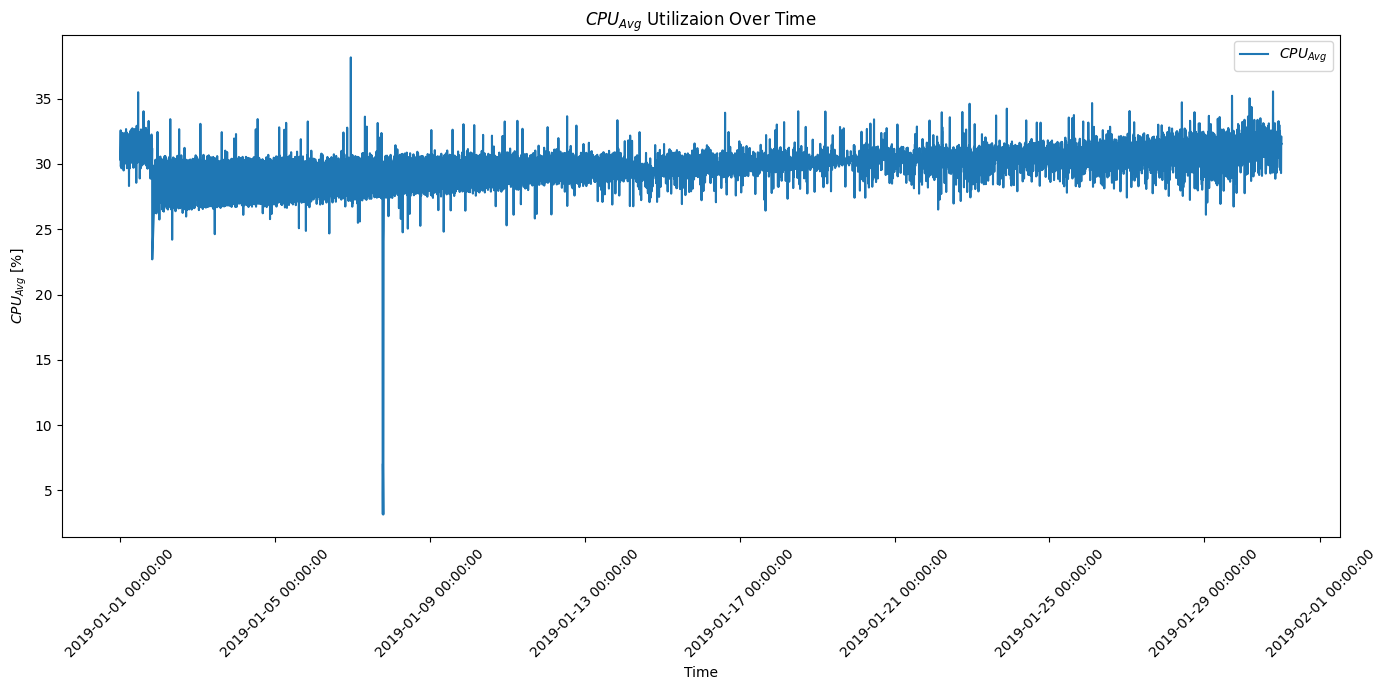

In [13]:
# Convert timestamp from epoch to datetime
data['timestamp'] = pd.to_datetime(data['timestamp'], unit='s')
# Sort the dataframe by timestamp
data.sort_index(inplace=True)

# Plot avgcpu to check for trend or seasonality
plt.figure(figsize=(14, 7))
sns.lineplot(data=data, x='timestamp', y='avgcpu', label='$CPU_{Avg}$')
plt.title('$CPU_{Avg}$ Utilizaion Over Time')

#step_size = 287
#selected_ticks = df['timestamp'][::step_size]
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M:%S'))
#plt.xticks(selected_ticks, rotation=90)

plt.xlabel('Time')
plt.ylabel('$CPU_{Avg}$ [%]')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# **select predictive models**

In [14]:
# Predict intervals using in-sample residuals
# ==============================================================================
in_sample_residuals=True

class SortDataFrame(BaseEstimator, TransformerMixin):
    def __init__(self, column_name):
        self.column_name = column_name

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X.sort_values(by=[self.column_name])


# Define custom transformers for the pipeline
class CheckSequence(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        if not isinstance(X.index, pd.DatetimeIndex):
            raise TypeError('Index must be a DatetimeIndex.')

        time_diffs = X.index.to_series().diff().dt.total_seconds()
        if not time_diffs[1:].eq(300).all():
            raise ValueError('Data is not equally sequenced with 5-minute intervals.')
        return X


class DataSplitter(BaseEstimator, TransformerMixin):
    def __init__(self, steps):
        self.steps = steps

    def fit(self, X, y=None):
        return self

    def transform(self, data):
        data_train = data[:-self.steps]
        data_test = data[-self.steps:]
        return data_train, data_test
from sklearn.base import BaseEstimator, TransformerMixin
import pandas as pd

class fill_nan_with_median(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        # Ensure X is a DataFrame and compute medians for later use
        if not isinstance(X, pd.DataFrame):
            raise ValueError("Input should be a pandas DataFrame.")

        self.median_values_ = {
            'avgcpu': X['avgcpu'].median(),
            'mincpu': X['mincpu'].median(),
            'maxcpu': X['maxcpu'].median()
        }

        return self
    def transform(self, X):
        # Ensure X is a DataFrame
        if not isinstance(X, pd.DataFrame):
            raise ValueError("Input should be a pandas DataFrame.")

        # Make a copy of the DataFrame to avoid modifying the original data
        X_filled = X.copy()

        # Fill NaN values with the computed medians
        for column in ['avgcpu', 'mincpu', 'maxcpu']:
            X_filled[column] = X_filled[column].fillna(self.median_values_[column])

        return X_filled

class fill_nan_with_linear(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        # Ensure X is a DataFrame
        if not isinstance(X, pd.DataFrame):
            raise ValueError("Input should be a pandas DataFrame.")
        return self

    def transform(self, X):
        # Ensure X is a DataFrame
        if not isinstance(X, pd.DataFrame):
            raise ValueError("Input should be a pandas DataFrame.")

        # Make a copy of the DataFrame to avoid modifying the original data
        X_interpolated = X.copy()

        # Fill NaN values using linear interpolation for specific columns
        X_interpolated[['avgcpu', 'mincpu', 'maxcpu']] = X_interpolated[['avgcpu', 'mincpu', 'maxcpu']].interpolate(method='linear')

        return X_interpolated

class fill_nan_with_nearest(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        # Ensure X is a DataFrame
        if not isinstance(X, pd.DataFrame):
            raise ValueError("Input should be a pandas DataFrame.")
        return self

    def transform(self, X):
        # Ensure X is a DataFrame
        if not isinstance(X, pd.DataFrame):
            raise ValueError("Input should be a pandas DataFrame.")

        # Make a copy of the DataFrame to avoid modifying the original data
        X_interpolated = X.copy()

        # Fill NaN values using nearest interpolation for specific columns
        X_interpolated[['avgcpu', 'mincpu', 'maxcpu']] = X_interpolated[['avgcpu', 'mincpu', 'maxcpu']].interpolate(method='nearest')

        return X_interpolated
class fill_nan_with_spline(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        # Ensure X is a DataFrame
        if not isinstance(X, pd.DataFrame):
            raise ValueError("Input should be a pandas DataFrame.")
        return self

    def transform(self, X):
        # Ensure X is a DataFrame
        if not isinstance(X, pd.DataFrame):
            raise ValueError("Input should be a pandas DataFrame.")

        # Make a copy of the DataFrame to avoid modifying the original data
        X_interpolated = X.copy()

        # Fill NaN values using spline interpolation for specific columns
        X_interpolated[['avgcpu', 'mincpu', 'maxcpu']] = X_interpolated[['avgcpu', 'mincpu', 'maxcpu']].interpolate(method='spline', order=1)

        return X_interpolated

class fill_nan_with_polynomial(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        # Ensure X is a DataFrame
        if not isinstance(X, pd.DataFrame):
            raise ValueError("Input should be a pandas DataFrame.")
        return self

    def transform(self, X):
        # Ensure X is a DataFrame
        if not isinstance(X, pd.DataFrame):
            raise ValueError("Input should be a pandas DataFrame.")

        # Make a copy of the DataFrame to avoid modifying the original data
        X_interpolated = X.copy()

        # Fill NaN values using polynomial interpolation for specific columns
        X_interpolated[['avgcpu', 'mincpu', 'maxcpu']] = X_interpolated[['avgcpu', 'mincpu', 'maxcpu']].interpolate(method='polynomial', order=1)

        return X_interpolated


class FillNaNWithDeepLearning(BaseEstimator, TransformerMixin):
    def __init__(self, columns=None,
                 n_steps=100,
                 n_features=1,
                 n_layers=2,
                 d_model=256,
                 n_heads=4,
                 d_k=64,
                 d_v=64,
                 d_ffn=128,
                 dropout=0.1,
                 epochs=50):
        self.columns = columns if columns is not None else []
        self.n_steps = n_steps
        self.n_features = n_features
        self.n_layers = n_layers
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k = d_k
        self.d_v = d_v
        self.d_ffn = d_ffn
        self.dropout = dropout
        self.epochs = epochs
        self.saits_models = {}

    def fit(self, X, y=None):
        if not isinstance(X, pd.DataFrame):
            raise ValueError("Input should be a pandas DataFrame.")

        for column in self.columns:
            if column not in X.columns:
                raise ValueError(f"Column {column} does not exist in input DataFrame.")

            # Create and fit a model for each column
            self.saits_models[column] = SAITS(n_steps=self.n_steps, n_features=self.n_features, n_layers=self.n_layers,
                                              d_model=self.d_model, n_heads=self.n_heads, d_k=self.d_k,
                                              d_v=self.d_v, d_ffn=self.d_ffn, dropout=self.dropout,
                                              epochs=self.epochs,verbose=0)

            # Prepare the data for the model by reshaping
            dataset = X[[column]].to_numpy()
            if len(dataset) % self.n_steps != 0:
                pad_size = self.n_steps - (len(dataset) % self.n_steps)  # Calculate padding size
                dataset = np.pad(dataset, ((0, pad_size), (0, 0)), mode='constant', constant_values=np.nan)

            dataset = dataset.reshape(-1, self.n_steps, self.n_features)  # Reshape correctly to 3D
            self.saits_models[column].fit({"X": dataset})  # Fit the model
            self.saits_models[column].save("saits.pypots", overwrite=True)
        return self
    def transform(self, X):
        if not isinstance(X, pd.DataFrame):
            raise ValueError("Input should be a pandas DataFrame.")

        X_imputed = X.copy()

        for column in self.columns:
            if column in self.saits_models:
                # Prepare the data for transformation by reshaping
                dataset = X[[column]].to_numpy()
                n_samples = dataset.shape[0]
                if n_samples < self.n_steps:
                    raise ValueError("Not enough samples in the dataset to reshape into 3D.")

                # Calculate padding size
                pad_size = self.n_steps - (n_samples % self.n_steps) if n_samples % self.n_steps != 0 else 0
                if pad_size > 0:
                    dataset = np.pad(dataset, ((0, pad_size), (0, 0)), mode='constant', constant_values=np.nan)

                # Re-shape
                dataset = dataset.reshape(-1, self.n_steps, self.n_features)

                # Impute missing values
                imputed_values = self.saits_models[column].impute({"X": dataset})
                imputed_values = imputed_values.flatten()

                # Remove any extra padded values to match the original DataFrame's length
                if len(imputed_values) > len(X_imputed):
                    imputed_values = imputed_values[:len(X_imputed)]

                # Ensure lengths match before assignment
                if len(imputed_values) != len(X_imputed):
                    raise ValueError(f"Imputed values length {len(imputed_values)} does not match the DataFrame length {len(X_imputed)}.")

                # Assign all rows for current column
                X_imputed.loc[:, column] = imputed_values

        return X_imputed


class FillMissingSequenceTimes(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        # Check if the index is a timestamp
        if not isinstance(X.index, pd.DatetimeIndex):
            raise KeyError("The DataFrame index is not a timestamp index.")

        start_time = X.index.min()
        end_time = X.index.max()
        # time_range = pd.date_range(start=start_time, end=end_time, freq='5T')  FutureWarning:
        time_range = pd.date_range(start=start_time, end=end_time, freq='5min')
        complete_df = pd.DataFrame(index=time_range)

        # Merge original DataFrame with the complete time range
        result_df = complete_df.join(X, how='left')
        return result_df

#  Define a custom transformer for adding vmid
class AddVmid(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        # X['vmid'] = X['vmid'].fillna(method='ffill')  ##warning
        X['vmid'] = X['vmid'].ffill() #
        return X

class ZScoreIQRDetector(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.threshold = 1.5

    def fit(self,columns, X, y=None):
        self.columns=columns
        self.X=X
        return self

    def transform(self, X):
        Q1 = X[self.columns].quantile(0.25)
        Q3 = X[self.columns].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - self.threshold * IQR
        upper_bound = Q3 + self.threshold * IQR

        # Calculate z-scores
        X['z_score'] = (X[self.columns] - X[self.columns].median()) / X[self.columns].std()

        # Identify outliers based on the IQR method
        X['is_outlier'] = ((X[self.columns] < lower_bound) | (X[self.columns] > upper_bound)).astype(int)

        # Replace global outliers with median of avgcpu
        X.loc[X['is_outlier'] == 1, self.columns] = X[self.columns].median()

        return X[[self.columns, 'z_score', 'is_outlier']]

class SavitzkyGolayFilter(BaseEstimator, TransformerMixin):
    def __init__(self, window_length=15, polyorder=2):
        self.window_length = window_length
        self.polyorder = polyorder

    def fit(self, X,column_name, y=None):
      self.column_name = column_name
      return self

    def transform(self, X):
        if self.column_name not in X.columns:
            raise ValueError(f"Column {self.column_name} does not exist in the DataFrame.")

        X_filtered = X.copy()
        X_filtered[self.column_name] = savgol_filter(X[self.column_name], window_length=self.window_length, polyorder=self.polyorder)

        return X_filtered

pre_processing_pipeline = Pipeline([
    ("check_Sequence", CheckSequence()),
    ("fill_missing_SequenceTimes", FillMissingSequenceTimes()),
])

fill_missing_pipeline = Pipeline([
    ("fill_nan_with_median",fill_nan_with_median()),
    ("fill_nan_with_linear",fill_nan_with_linear()),
    ("fill_nan_with_nearest",fill_nan_with_nearest()),
    ("fill_nan_with_spline",fill_nan_with_spline()),
    ("fill_nan_with_polynomial",fill_nan_with_polynomial()),
    ("FillNaNWithDeepLearning",FillNaNWithDeepLearning(columns=['avgcpu', 'mincpu', 'maxcpu'],n_features=1)),

    ("AddVmid" , AddVmid()),

])

z_score_pipeline = Pipeline([
    ("Clip",ZScoreIQRDetector())
])

denoising_pipeline = Pipeline([
     ("DE_noising",SavitzkyGolayFilter()),
])


used_pipeline_in_sample_residual = Pipeline([
    ("sort_by_timestamp",  FeatureUnion([('SortDataFrame',       SortDataFrame("timestamp"))])),
    ('sub_preprocessing',  FeatureUnion([('pre_processing',      pre_processing_pipeline)])),
    ('sub_fill_nan',       FeatureUnion([('FillMissingValues',   fill_missing_pipeline)])),
    ('sub_ClipOvershoots', FeatureUnion([('ClipOvershoots',      z_score_pipeline)])),
    ('sub_denoising',      FeatureUnion([('denoising_Filter',    denoising_pipeline)])),

])

used_pipeline_in_sample_residual

Pipeline(steps=[('sort_by_timestamp',
                 FeatureUnion(transformer_list=[('SortDataFrame',
                                                 SortDataFrame(column_name='timestamp'))])),
                ('sub_preprocessing',
                 FeatureUnion(transformer_list=[('pre_processing',
                                                 Pipeline(steps=[('check_Sequence',
                                                                  CheckSequence()),
                                                                 ('fill_missing_SequenceTimes',
                                                                  FillMissingSequenceTimes())]))])),
                ('sub_fill_nan',
                 FeatureUnion(transfor...
                                                                 ('FillNaNWithDeepLearning',
                                                                  FillNaNWithDeepLearning(columns=['avgcpu',
                                                                                                   'mincpu',
                                                                                                   'maxcpu'])),
                                                                 ('AddVmid',
                                                                  AddVmid())]))])),
                ('sub_ClipOvershoots',
                 FeatureUnion(transformer_list=[('ClipOvershoots',
                                                 Pipeline(steps=[('Clip',
                                                                  ZScoreIQRDetector())]))])),
                ('sub_denoising',
                 FeatureUnion(transformer_list=[('denoising_Filter',
                                                 Pipeline(steps=[('DE_noising',
                                                                  SavitzkyGolayFilter())]))]))])

In [15]:
sort_data_time = used_pipeline_in_sample_residual.get_params()['sort_by_timestamp__SortDataFrame']
sorted_df = sort_data_time.transform(data)

In [16]:
sorted_df

,timestamp,vmid,mincpu,maxcpu,avgcpu
891,2019-01-01 00:00:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,5.856217,59.313485,30.343212
892,2019-01-01 00:05:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,5.860725,61.584032,31.316150
893,2019-01-01 00:10:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,5.632154,63.847679,32.042686
894,2019-01-01 00:15:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,4.940414,63.833219,32.574491
895,2019-01-01 00:20:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,3.974400,60.950340,29.807146
...,...,...,...,...,...
5239,2019-01-30 23:30:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,3.646091,60.887985,29.314015
5240,2019-01-30 23:35:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,5.709531,62.776805,29.299661
5241,2019-01-30 23:40:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,11.666832,64.595622,31.602566
5242,2019-01-30 23:45:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,4.956652,63.914229,31.492256


In [17]:
check_processing_data = used_pipeline_in_sample_residual.get_params()['sub_preprocessing__pre_processing__check_Sequence']
sorted_df['timestamp'] = pd.to_datetime(sorted_df['timestamp'])  # Convert the column to datetime
sorted_df.set_index('timestamp', inplace=True)                   # Set it as the index
check_Sequence = check_processing_data.fit_transform(sorted_df)


ValueError: Data is not equally sequenced with 5-minute intervals.

# Detect and Filter missing records and missing gaps

In [18]:
fill_missing_times_processing = used_pipeline_in_sample_residual.get_params()['sub_preprocessing__pre_processing__fill_missing_SequenceTimes']
fill_missing_times_df         = fill_missing_times_processing.fit_transform(sorted_df)
fill_missing_times_df

,vmid,mincpu,maxcpu,avgcpu
2019-01-01 00:00:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,5.856217,59.313485,30.343212
2019-01-01 00:05:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,5.860725,61.584032,31.316150
2019-01-01 00:10:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,5.632154,63.847679,32.042686
2019-01-01 00:15:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,4.940414,63.833219,32.574491
2019-01-01 00:20:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,3.974400,60.950340,29.807146
...,...,...,...,...
2019-01-30 23:30:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,3.646091,60.887985,29.314015
2019-01-30 23:35:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,5.709531,62.776805,29.299661
2019-01-30 23:40:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,11.666832,64.595622,31.602566
2019-01-30 23:45:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,4.956652,63.914229,31.492256


In [19]:
fill_missing_times_df.shape

(8639, 4)

In [20]:
fill_missing_times_df.isna().sum()

,0
vmid,14
mincpu,14
maxcpu,14
avgcpu,14


In [21]:
print(fill_missing_times_df[['avgcpu','mincpu', 'maxcpu']].isna().sum())

avgcpu    14
mincpu    14
maxcpu    14
dtype: int64


In [22]:
fill_missing_times_df['fixed_records'] = fill_missing_times_df['avgcpu'].isna().astype(int)
missing_records_with_NaN               = fill_missing_times_df[fill_missing_times_df['fixed_records'] == 1]
missing_records_with_NaN

,vmid,mincpu,maxcpu,avgcpu,fixed_records
2019-01-01 19:55:00,NaN,NaN,NaN,NaN,1
2019-01-01 20:00:00,NaN,NaN,NaN,NaN,1
2019-01-01 20:05:00,NaN,NaN,NaN,NaN,1
2019-01-01 20:10:00,NaN,NaN,NaN,NaN,1
2019-01-01 20:15:00,NaN,NaN,NaN,NaN,1
2019-01-01 20:20:00,NaN,NaN,NaN,NaN,1
2019-01-01 20:25:00,NaN,NaN,NaN,NaN,1
2019-01-01 20:30:00,NaN,NaN,NaN,NaN,1
2019-01-01 20:35:00,NaN,NaN,NaN,NaN,1
2019-01-01 20:40:00,NaN,NaN,NaN,NaN,1


# Apply imputations methods over missing data

#### fill_nan_with_median

In [23]:
filler_median = used_pipeline_in_sample_residual.get_params()['sub_fill_nan__FillMissingValues__fill_nan_with_median']
filler_median.fit(fill_missing_times_df)
df_filled1 = filler_median.transform(fill_missing_times_df)
df_filled1

,vmid,mincpu,maxcpu,avgcpu,fixed_records
2019-01-01 00:00:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,5.856217,59.313485,30.343212,0
2019-01-01 00:05:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,5.860725,61.584032,31.316150,0
2019-01-01 00:10:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,5.632154,63.847679,32.042686,0
2019-01-01 00:15:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,4.940414,63.833219,32.574491,0
2019-01-01 00:20:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,3.974400,60.950340,29.807146,0
...,...,...,...,...,...
2019-01-30 23:30:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,3.646091,60.887985,29.314015,0
2019-01-30 23:35:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,5.709531,62.776805,29.299661,0
2019-01-30 23:40:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,11.666832,64.595622,31.602566,0
2019-01-30 23:45:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,4.956652,63.914229,31.492256,0


In [24]:
df_filled1.shape

(8639, 5)

In [25]:
df_filled1.isna().sum()

,0
vmid,14
mincpu,0
maxcpu,0
avgcpu,0
fixed_records,0


In [26]:
imputed_NaN_values_records = df_filled1[df_filled1['fixed_records'] == 1]
imputed_NaN_values_records

,vmid,mincpu,maxcpu,avgcpu,fixed_records
2019-01-01 19:55:00,NaN,4.544373,64.995265,30.046995,1
2019-01-01 20:00:00,NaN,4.544373,64.995265,30.046995,1
2019-01-01 20:05:00,NaN,4.544373,64.995265,30.046995,1
2019-01-01 20:10:00,NaN,4.544373,64.995265,30.046995,1
2019-01-01 20:15:00,NaN,4.544373,64.995265,30.046995,1
2019-01-01 20:20:00,NaN,4.544373,64.995265,30.046995,1
2019-01-01 20:25:00,NaN,4.544373,64.995265,30.046995,1
2019-01-01 20:30:00,NaN,4.544373,64.995265,30.046995,1
2019-01-01 20:35:00,NaN,4.544373,64.995265,30.046995,1
2019-01-01 20:40:00,NaN,4.544373,64.995265,30.046995,1


In [27]:
addVmiddata= used_pipeline_in_sample_residual.get_params()['sub_fill_nan__FillMissingValues__AddVmid']
df_final1=addVmiddata.transform(df_filled1)


In [28]:
df_final1

,vmid,mincpu,maxcpu,avgcpu,fixed_records
2019-01-01 00:00:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,5.856217,59.313485,30.343212,0
2019-01-01 00:05:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,5.860725,61.584032,31.316150,0
2019-01-01 00:10:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,5.632154,63.847679,32.042686,0
2019-01-01 00:15:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,4.940414,63.833219,32.574491,0
2019-01-01 00:20:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,3.974400,60.950340,29.807146,0
...,...,...,...,...,...
2019-01-30 23:30:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,3.646091,60.887985,29.314015,0
2019-01-30 23:35:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,5.709531,62.776805,29.299661,0
2019-01-30 23:40:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,11.666832,64.595622,31.602566,0
2019-01-30 23:45:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,4.956652,63.914229,31.492256,0


In [29]:
df_final1.isna().sum()

,0
vmid,0
mincpu,0
maxcpu,0
avgcpu,0
fixed_records,0


In [30]:
imputed_NaN_values_records = df_final1[df_final1['fixed_records'] == 1]
imputed_NaN_values_records

,vmid,mincpu,maxcpu,avgcpu,fixed_records
2019-01-01 19:55:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,4.544373,64.995265,30.046995,1
2019-01-01 20:00:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,4.544373,64.995265,30.046995,1
2019-01-01 20:05:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,4.544373,64.995265,30.046995,1
2019-01-01 20:10:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,4.544373,64.995265,30.046995,1
2019-01-01 20:15:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,4.544373,64.995265,30.046995,1
2019-01-01 20:20:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,4.544373,64.995265,30.046995,1
2019-01-01 20:25:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,4.544373,64.995265,30.046995,1
2019-01-01 20:30:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,4.544373,64.995265,30.046995,1
2019-01-01 20:35:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,4.544373,64.995265,30.046995,1
2019-01-01 20:40:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,4.544373,64.995265,30.046995,1


#### Interpolation(Linear)

In [31]:
filler_linear = used_pipeline_in_sample_residual.get_params()['sub_fill_nan__FillMissingValues__fill_nan_with_linear']
filler_linear.fit(fill_missing_times_df)
df_filled2 = filler_linear.transform(fill_missing_times_df)
df_filled2

,vmid,mincpu,maxcpu,avgcpu,fixed_records
2019-01-01 00:00:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,5.856217,59.313485,30.343212,0
2019-01-01 00:05:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,5.860725,61.584032,31.316150,0
2019-01-01 00:10:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,5.632154,63.847679,32.042686,0
2019-01-01 00:15:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,4.940414,63.833219,32.574491,0
2019-01-01 00:20:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,3.974400,60.950340,29.807146,0
...,...,...,...,...,...
2019-01-30 23:30:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,3.646091,60.887985,29.314015,0
2019-01-30 23:35:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,5.709531,62.776805,29.299661,0
2019-01-30 23:40:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,11.666832,64.595622,31.602566,0
2019-01-30 23:45:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,4.956652,63.914229,31.492256,0


In [32]:
df_filled2.shape

(8639, 5)

In [33]:
df_filled2.isna().sum()

,0
vmid,14
mincpu,0
maxcpu,0
avgcpu,0
fixed_records,0


In [34]:
imputed_NaN_values_records = df_filled2[df_filled2['fixed_records'] == 1]
imputed_NaN_values_records

,vmid,mincpu,maxcpu,avgcpu,fixed_records
2019-01-01 19:55:00,NaN,3.981651,55.249407,22.991876,1
2019-01-01 20:00:00,NaN,3.799582,56.462500,23.291880,1
2019-01-01 20:05:00,NaN,3.617514,57.675592,23.591885,1
2019-01-01 20:10:00,NaN,3.435445,58.888685,23.891890,1
2019-01-01 20:15:00,NaN,3.253377,60.101778,24.191894,1
2019-01-01 20:20:00,NaN,3.071308,61.314870,24.491899,1
2019-01-01 20:25:00,NaN,2.889240,62.527963,24.791904,1
2019-01-01 20:30:00,NaN,2.707171,63.741056,25.091908,1
2019-01-01 20:35:00,NaN,2.525103,64.954148,25.391913,1
2019-01-01 20:40:00,NaN,2.343034,66.167241,25.691918,1


In [35]:
addVmiddata= used_pipeline_in_sample_residual.get_params()['sub_fill_nan__FillMissingValues__AddVmid']
df_final2=addVmiddata.transform(df_filled2)


In [36]:
df_final2

,vmid,mincpu,maxcpu,avgcpu,fixed_records
2019-01-01 00:00:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,5.856217,59.313485,30.343212,0
2019-01-01 00:05:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,5.860725,61.584032,31.316150,0
2019-01-01 00:10:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,5.632154,63.847679,32.042686,0
2019-01-01 00:15:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,4.940414,63.833219,32.574491,0
2019-01-01 00:20:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,3.974400,60.950340,29.807146,0
...,...,...,...,...,...
2019-01-30 23:30:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,3.646091,60.887985,29.314015,0
2019-01-30 23:35:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,5.709531,62.776805,29.299661,0
2019-01-30 23:40:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,11.666832,64.595622,31.602566,0
2019-01-30 23:45:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,4.956652,63.914229,31.492256,0


In [37]:
df_final2.isna().sum()

,0
vmid,0
mincpu,0
maxcpu,0
avgcpu,0
fixed_records,0


In [38]:
imputed_NaN_values_records = df_final2[df_final2['fixed_records'] == 1]
imputed_NaN_values_records

,vmid,mincpu,maxcpu,avgcpu,fixed_records
2019-01-01 19:55:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,3.981651,55.249407,22.991876,1
2019-01-01 20:00:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,3.799582,56.462500,23.291880,1
2019-01-01 20:05:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,3.617514,57.675592,23.591885,1
2019-01-01 20:10:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,3.435445,58.888685,23.891890,1
2019-01-01 20:15:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,3.253377,60.101778,24.191894,1
2019-01-01 20:20:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,3.071308,61.314870,24.491899,1
2019-01-01 20:25:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,2.889240,62.527963,24.791904,1
2019-01-01 20:30:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,2.707171,63.741056,25.091908,1
2019-01-01 20:35:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,2.525103,64.954148,25.391913,1
2019-01-01 20:40:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,2.343034,66.167241,25.691918,1


#### Interpolation(nearest)

In [39]:
filler_nearest = used_pipeline_in_sample_residual.get_params()['sub_fill_nan__FillMissingValues__fill_nan_with_nearest']
filler_nearest.fit(fill_missing_times_df)
df_filled3 = filler_nearest.transform(fill_missing_times_df)
df_filled3

,vmid,mincpu,maxcpu,avgcpu,fixed_records
2019-01-01 00:00:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,5.856217,59.313485,30.343212,0
2019-01-01 00:05:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,5.860725,61.584032,31.316150,0
2019-01-01 00:10:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,5.632154,63.847679,32.042686,0
2019-01-01 00:15:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,4.940414,63.833219,32.574491,0
2019-01-01 00:20:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,3.974400,60.950340,29.807146,0
...,...,...,...,...,...
2019-01-30 23:30:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,3.646091,60.887985,29.314015,0
2019-01-30 23:35:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,5.709531,62.776805,29.299661,0
2019-01-30 23:40:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,11.666832,64.595622,31.602566,0
2019-01-30 23:45:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,4.956652,63.914229,31.492256,0


In [40]:
df_filled3.shape

(8639, 5)

In [41]:
df_filled3.isna().sum()

,0
vmid,14
mincpu,0
maxcpu,0
avgcpu,0
fixed_records,0


In [42]:
imputed_NaN_values_records = df_filled3[df_filled3['fixed_records'] == 1]
imputed_NaN_values_records

,vmid,mincpu,maxcpu,avgcpu,fixed_records
2019-01-01 19:55:00,NaN,4.163719,54.036315,22.691871,1
2019-01-01 20:00:00,NaN,4.163719,54.036315,22.691871,1
2019-01-01 20:05:00,NaN,4.163719,54.036315,22.691871,1
2019-01-01 20:10:00,NaN,4.163719,54.036315,22.691871,1
2019-01-01 20:15:00,NaN,4.163719,54.036315,22.691871,1
2019-01-01 20:20:00,NaN,4.163719,54.036315,22.691871,1
2019-01-01 20:25:00,NaN,1.796829,69.806519,26.591932,1
2019-01-01 20:30:00,NaN,1.796829,69.806519,26.591932,1
2019-01-01 20:35:00,NaN,1.796829,69.806519,26.591932,1
2019-01-01 20:40:00,NaN,1.796829,69.806519,26.591932,1


In [43]:
addVmiddata= used_pipeline_in_sample_residual.get_params()['sub_fill_nan__FillMissingValues__AddVmid']
df_final3=addVmiddata.transform(df_filled3)


In [44]:
df_final3

,vmid,mincpu,maxcpu,avgcpu,fixed_records
2019-01-01 00:00:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,5.856217,59.313485,30.343212,0
2019-01-01 00:05:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,5.860725,61.584032,31.316150,0
2019-01-01 00:10:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,5.632154,63.847679,32.042686,0
2019-01-01 00:15:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,4.940414,63.833219,32.574491,0
2019-01-01 00:20:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,3.974400,60.950340,29.807146,0
...,...,...,...,...,...
2019-01-30 23:30:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,3.646091,60.887985,29.314015,0
2019-01-30 23:35:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,5.709531,62.776805,29.299661,0
2019-01-30 23:40:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,11.666832,64.595622,31.602566,0
2019-01-30 23:45:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,4.956652,63.914229,31.492256,0


In [45]:
df_final3.isna().sum()

,0
vmid,0
mincpu,0
maxcpu,0
avgcpu,0
fixed_records,0


In [46]:
imputed_NaN_values_records = df_final3[df_final3['fixed_records'] == 1]
imputed_NaN_values_records

,vmid,mincpu,maxcpu,avgcpu,fixed_records
2019-01-01 19:55:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,4.163719,54.036315,22.691871,1
2019-01-01 20:00:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,4.163719,54.036315,22.691871,1
2019-01-01 20:05:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,4.163719,54.036315,22.691871,1
2019-01-01 20:10:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,4.163719,54.036315,22.691871,1
2019-01-01 20:15:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,4.163719,54.036315,22.691871,1
2019-01-01 20:20:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,4.163719,54.036315,22.691871,1
2019-01-01 20:25:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,1.796829,69.806519,26.591932,1
2019-01-01 20:30:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,1.796829,69.806519,26.591932,1
2019-01-01 20:35:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,1.796829,69.806519,26.591932,1
2019-01-01 20:40:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,1.796829,69.806519,26.591932,1


#### Interpolation(spline)

In [47]:
filler_spline = used_pipeline_in_sample_residual.get_params()['sub_fill_nan__FillMissingValues__fill_nan_with_spline']
filler_spline.fit(fill_missing_times_df)
df_filled4 = filler_spline.transform(fill_missing_times_df)
df_filled4

,vmid,mincpu,maxcpu,avgcpu,fixed_records
2019-01-01 00:00:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,5.856217,59.313485,30.343212,0
2019-01-01 00:05:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,5.860725,61.584032,31.316150,0
2019-01-01 00:10:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,5.632154,63.847679,32.042686,0
2019-01-01 00:15:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,4.940414,63.833219,32.574491,0
2019-01-01 00:20:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,3.974400,60.950340,29.807146,0
...,...,...,...,...,...
2019-01-30 23:30:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,3.646091,60.887985,29.314015,0
2019-01-30 23:35:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,5.709531,62.776805,29.299661,0
2019-01-30 23:40:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,11.666832,64.595622,31.602566,0
2019-01-30 23:45:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,4.956652,63.914229,31.492256,0


In [48]:
df_filled4.shape

(8639, 5)

In [49]:
df_filled4.isna().sum()

,0
vmid,14
mincpu,0
maxcpu,0
avgcpu,0
fixed_records,0


In [50]:
imputed_NaN_values_records = df_filled4[df_filled4['fixed_records'] == 1]
imputed_NaN_values_records

,vmid,mincpu,maxcpu,avgcpu,fixed_records
2019-01-01 19:55:00,NaN,4.152786,54.730065,26.306700,1
2019-01-01 20:00:00,NaN,3.958778,55.980692,26.410573,1
2019-01-01 20:05:00,NaN,3.764769,57.231320,26.514445,1
2019-01-01 20:10:00,NaN,3.570761,58.481947,26.618317,1
2019-01-01 20:15:00,NaN,3.376753,59.732574,26.722189,1
2019-01-01 20:20:00,NaN,3.182744,60.983202,26.826062,1
2019-01-01 20:25:00,NaN,2.988736,62.233829,26.929934,1
2019-01-01 20:30:00,NaN,2.794728,63.484456,27.033806,1
2019-01-01 20:35:00,NaN,2.600719,64.735083,27.137678,1
2019-01-01 20:40:00,NaN,2.406711,65.985711,27.241551,1


In [51]:
addVmiddata= used_pipeline_in_sample_residual.get_params()['sub_fill_nan__FillMissingValues__AddVmid']
df_final4=addVmiddata.transform(df_filled4)


In [52]:
df_final4

,vmid,mincpu,maxcpu,avgcpu,fixed_records
2019-01-01 00:00:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,5.856217,59.313485,30.343212,0
2019-01-01 00:05:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,5.860725,61.584032,31.316150,0
2019-01-01 00:10:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,5.632154,63.847679,32.042686,0
2019-01-01 00:15:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,4.940414,63.833219,32.574491,0
2019-01-01 00:20:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,3.974400,60.950340,29.807146,0
...,...,...,...,...,...
2019-01-30 23:30:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,3.646091,60.887985,29.314015,0
2019-01-30 23:35:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,5.709531,62.776805,29.299661,0
2019-01-30 23:40:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,11.666832,64.595622,31.602566,0
2019-01-30 23:45:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,4.956652,63.914229,31.492256,0


In [53]:
df_final4.isna().sum()

,0
vmid,0
mincpu,0
maxcpu,0
avgcpu,0
fixed_records,0


In [54]:
imputed_NaN_values_records = df_final4[df_final4['fixed_records'] == 1]
imputed_NaN_values_records

,vmid,mincpu,maxcpu,avgcpu,fixed_records
2019-01-01 19:55:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,4.152786,54.730065,26.306700,1
2019-01-01 20:00:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,3.958778,55.980692,26.410573,1
2019-01-01 20:05:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,3.764769,57.231320,26.514445,1
2019-01-01 20:10:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,3.570761,58.481947,26.618317,1
2019-01-01 20:15:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,3.376753,59.732574,26.722189,1
2019-01-01 20:20:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,3.182744,60.983202,26.826062,1
2019-01-01 20:25:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,2.988736,62.233829,26.929934,1
2019-01-01 20:30:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,2.794728,63.484456,27.033806,1
2019-01-01 20:35:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,2.600719,64.735083,27.137678,1
2019-01-01 20:40:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,2.406711,65.985711,27.241551,1


#### Interpolation(polynomial)

In [55]:
filler_polynomial = used_pipeline_in_sample_residual.get_params()['sub_fill_nan__FillMissingValues__fill_nan_with_polynomial']
filler_polynomial.fit(fill_missing_times_df)
df_filled5 = filler_polynomial.transform(fill_missing_times_df)
df_filled5

,vmid,mincpu,maxcpu,avgcpu,fixed_records
2019-01-01 00:00:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,5.856217,59.313485,30.343212,0
2019-01-01 00:05:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,5.860725,61.584032,31.316150,0
2019-01-01 00:10:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,5.632154,63.847679,32.042686,0
2019-01-01 00:15:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,4.940414,63.833219,32.574491,0
2019-01-01 00:20:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,3.974400,60.950340,29.807146,0
...,...,...,...,...,...
2019-01-30 23:30:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,3.646091,60.887985,29.314015,0
2019-01-30 23:35:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,5.709531,62.776805,29.299661,0
2019-01-30 23:40:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,11.666832,64.595622,31.602566,0
2019-01-30 23:45:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,4.956652,63.914229,31.492256,0


In [56]:
df_filled5.shape

(8639, 5)

In [57]:
df_filled5.isna().sum()

,0
vmid,14
mincpu,0
maxcpu,0
avgcpu,0
fixed_records,0


In [58]:
imputed_NaN_values_records = df_filled5[df_filled5['fixed_records'] == 1]
imputed_NaN_values_records

,vmid,mincpu,maxcpu,avgcpu,fixed_records
2019-01-01 19:55:00,NaN,3.981651,55.249407,22.991876,1
2019-01-01 20:00:00,NaN,3.799582,56.462500,23.291880,1
2019-01-01 20:05:00,NaN,3.617514,57.675592,23.591885,1
2019-01-01 20:10:00,NaN,3.435445,58.888685,23.891890,1
2019-01-01 20:15:00,NaN,3.253377,60.101778,24.191894,1
2019-01-01 20:20:00,NaN,3.071308,61.314870,24.491899,1
2019-01-01 20:25:00,NaN,2.889240,62.527963,24.791904,1
2019-01-01 20:30:00,NaN,2.707171,63.741056,25.091908,1
2019-01-01 20:35:00,NaN,2.525103,64.954148,25.391913,1
2019-01-01 20:40:00,NaN,2.343034,66.167241,25.691918,1


In [59]:
addVmiddata= used_pipeline_in_sample_residual.get_params()['sub_fill_nan__FillMissingValues__AddVmid']
df_final5=addVmiddata.transform(df_filled5)


In [60]:
df_final4

,vmid,mincpu,maxcpu,avgcpu,fixed_records
2019-01-01 00:00:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,5.856217,59.313485,30.343212,0
2019-01-01 00:05:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,5.860725,61.584032,31.316150,0
2019-01-01 00:10:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,5.632154,63.847679,32.042686,0
2019-01-01 00:15:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,4.940414,63.833219,32.574491,0
2019-01-01 00:20:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,3.974400,60.950340,29.807146,0
...,...,...,...,...,...
2019-01-30 23:30:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,3.646091,60.887985,29.314015,0
2019-01-30 23:35:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,5.709531,62.776805,29.299661,0
2019-01-30 23:40:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,11.666832,64.595622,31.602566,0
2019-01-30 23:45:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,4.956652,63.914229,31.492256,0


In [61]:
df_final5.isna().sum()

,0
vmid,0
mincpu,0
maxcpu,0
avgcpu,0
fixed_records,0


In [62]:
imputed_NaN_values_records = df_final5[df_final5['fixed_records'] == 1]
imputed_NaN_values_records

,vmid,mincpu,maxcpu,avgcpu,fixed_records
2019-01-01 19:55:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,3.981651,55.249407,22.991876,1
2019-01-01 20:00:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,3.799582,56.462500,23.291880,1
2019-01-01 20:05:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,3.617514,57.675592,23.591885,1
2019-01-01 20:10:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,3.435445,58.888685,23.891890,1
2019-01-01 20:15:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,3.253377,60.101778,24.191894,1
2019-01-01 20:20:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,3.071308,61.314870,24.491899,1
2019-01-01 20:25:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,2.889240,62.527963,24.791904,1
2019-01-01 20:30:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,2.707171,63.741056,25.091908,1
2019-01-01 20:35:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,2.525103,64.954148,25.391913,1
2019-01-01 20:40:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,2.343034,66.167241,25.691918,1


#### Fill NaN With DeepLearning

In [63]:
filler_DeepLearning = used_pipeline_in_sample_residual.get_params()['sub_fill_nan__FillMissingValues__FillNaNWithDeepLearning']
filler_DeepLearning.fit(fill_missing_times_df)


2025-03-17 20:42:52 [WARNING]: ‼️ saving_path not given. Model files and tensorboard file will not be saved.
2025-03-17 20:47:06 [WARNING]: ‼️ saving_path not given. Model files and tensorboard file will not be saved.
2025-03-17 20:50:15 [WARNING]: ‼️ File ./saits.pypots exists. Argument `overwrite` is True. Overwriting now...
2025-03-17 20:50:15 [WARNING]: ‼️ saving_path not given. Model files and tensorboard file will not be saved.
2025-03-17 20:54:10 [WARNING]: ‼️ File ./saits.pypots exists. Argument `overwrite` is True. Overwriting now...


FillNaNWithDeepLearning(columns=['avgcpu', 'mincpu', 'maxcpu'])

In [64]:
filler_DeepLearning

FillNaNWithDeepLearning(columns=['avgcpu', 'mincpu', 'maxcpu'])

In [65]:
df_filled6 = filler_DeepLearning.transform(fill_missing_times_df)
df_filled6

,vmid,mincpu,maxcpu,avgcpu,fixed_records
2019-01-01 00:00:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,5.856217,59.313484,30.343212,0
2019-01-01 00:05:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,5.860725,61.584034,31.316151,0
2019-01-01 00:10:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,5.632154,63.847679,32.042686,0
2019-01-01 00:15:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,4.940414,63.833218,32.574490,0
2019-01-01 00:20:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,3.974400,60.950340,29.807146,0
...,...,...,...,...,...
2019-01-30 23:30:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,3.646091,60.887985,29.314014,0
2019-01-30 23:35:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,5.709531,62.776806,29.299662,0
2019-01-30 23:40:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,11.666832,64.595619,31.602566,0
2019-01-30 23:45:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,4.956652,63.914230,31.492256,0


In [66]:
df_filled6.shape

(8639, 5)

In [67]:
df_filled6.isna().sum()

,0
vmid,14
mincpu,0
maxcpu,0
avgcpu,0
fixed_records,0


In [68]:
imputed_NaN_values_records = df_filled6[df_filled6['fixed_records'] == 1]
imputed_NaN_values_records

,vmid,mincpu,maxcpu,avgcpu,fixed_records
2019-01-01 19:55:00,NaN,5.702246,40.569656,30.736153,1
2019-01-01 20:00:00,NaN,5.716518,40.567303,30.735664,1
2019-01-01 20:05:00,NaN,5.692212,40.566738,30.735500,1
2019-01-01 20:10:00,NaN,5.655171,40.569904,30.735235,1
2019-01-01 20:15:00,NaN,5.629189,40.570755,30.735804,1
2019-01-01 20:20:00,NaN,5.622434,40.568642,30.733650,1
2019-01-01 20:25:00,NaN,5.625945,40.570637,30.735905,1
2019-01-01 20:30:00,NaN,5.626302,40.571514,30.737724,1
2019-01-01 20:35:00,NaN,5.616488,40.572071,30.739296,1
2019-01-01 20:40:00,NaN,5.599627,40.569862,30.737427,1


In [69]:
addVmiddata= used_pipeline_in_sample_residual.get_params()['sub_fill_nan__FillMissingValues__AddVmid']
df_final6=addVmiddata.transform(df_filled6)


In [70]:
df_final6

,vmid,mincpu,maxcpu,avgcpu,fixed_records
2019-01-01 00:00:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,5.856217,59.313484,30.343212,0
2019-01-01 00:05:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,5.860725,61.584034,31.316151,0
2019-01-01 00:10:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,5.632154,63.847679,32.042686,0
2019-01-01 00:15:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,4.940414,63.833218,32.574490,0
2019-01-01 00:20:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,3.974400,60.950340,29.807146,0
...,...,...,...,...,...
2019-01-30 23:30:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,3.646091,60.887985,29.314014,0
2019-01-30 23:35:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,5.709531,62.776806,29.299662,0
2019-01-30 23:40:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,11.666832,64.595619,31.602566,0
2019-01-30 23:45:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,4.956652,63.914230,31.492256,0


In [71]:
df_final6.isna().sum()

,0
vmid,0
mincpu,0
maxcpu,0
avgcpu,0
fixed_records,0


In [72]:
imputed_NaN_values_records = df_final6[df_final6['fixed_records'] == 1]
imputed_NaN_values_records

,vmid,mincpu,maxcpu,avgcpu,fixed_records
2019-01-01 19:55:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,5.702246,40.569656,30.736153,1
2019-01-01 20:00:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,5.716518,40.567303,30.735664,1
2019-01-01 20:05:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,5.692212,40.566738,30.735500,1
2019-01-01 20:10:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,5.655171,40.569904,30.735235,1
2019-01-01 20:15:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,5.629189,40.570755,30.735804,1
2019-01-01 20:20:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,5.622434,40.568642,30.733650,1
2019-01-01 20:25:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,5.625945,40.570637,30.735905,1
2019-01-01 20:30:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,5.626302,40.571514,30.737724,1
2019-01-01 20:35:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,5.616488,40.572071,30.739296,1
2019-01-01 20:40:00,//20EFdlSE3atYr9P03/9X4nF16d9RXI+JKVFfvpC281oh...,5.599627,40.569862,30.737427,1


# Visualize and compare the imputation results

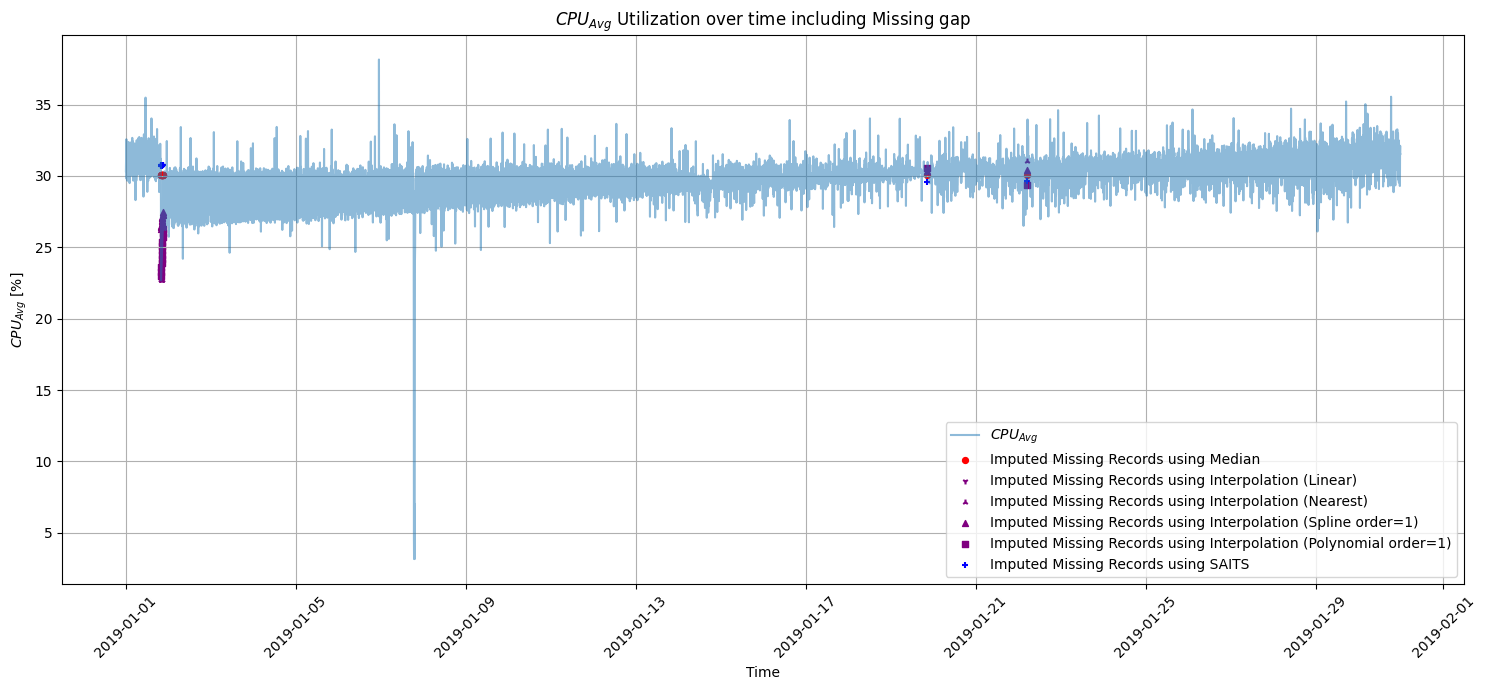

In [73]:
import matplotlib.pyplot as plt

# Filter the records that have been added
imputed_NaN_values_records1 = df_final1[df_final1['fixed_records'] == 1]
imputed_NaN_values_records2 = df_final2[df_final2['fixed_records'] == 1]
imputed_NaN_values_records3 = df_final3[df_final3['fixed_records'] == 1]
imputed_NaN_values_records4 = df_final4[df_final4['fixed_records'] == 1]
imputed_NaN_values_records5 = df_final5[df_final5['fixed_records'] == 1]
imputed_NaN_values_records6 = df_final6[df_final6['fixed_records'] == 1]
# Plot the original data with missing records highlighted and annotated
plt.figure(figsize=(15, 7))
sns.lineplot(data=data, x='timestamp', y='avgcpu', label='$CPU_{Avg}$', alpha=0.5)
plt.scatter(imputed_NaN_values_records1.index, imputed_NaN_values_records1['avgcpu'], color='r', label='Imputed Missing Records using Median', marker='o', s=18)
plt.scatter(imputed_NaN_values_records2.index, imputed_NaN_values_records2['avgcpu'], color='#800080', label='Imputed Missing Records using Interpolation (Linear)', marker='1', s=18)
plt.scatter(imputed_NaN_values_records3.index, imputed_NaN_values_records3['avgcpu'], color='#800080', label='Imputed Missing Records using Interpolation (Nearest)', marker='2', s=18)
plt.scatter(imputed_NaN_values_records4.index, imputed_NaN_values_records4['avgcpu'], color='#800080', label='Imputed Missing Records using Interpolation (Spline order=1)', marker='^', s=18)
plt.scatter(imputed_NaN_values_records5.index, imputed_NaN_values_records5['avgcpu'], color='#800080', label='Imputed Missing Records using Interpolation (Polynomial order=1)', marker='s', s=18)
plt.scatter(imputed_NaN_values_records6.index, imputed_NaN_values_records6['avgcpu'], color='b', label='Imputed Missing Records using SAITS', marker='+', s=18)

plt.title('$CPU_{Avg}$ Utilization over time including Missing gap')
plt.xlabel('Time')
plt.ylabel('$CPU_{Avg}$ [%]')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid()
plt.show()

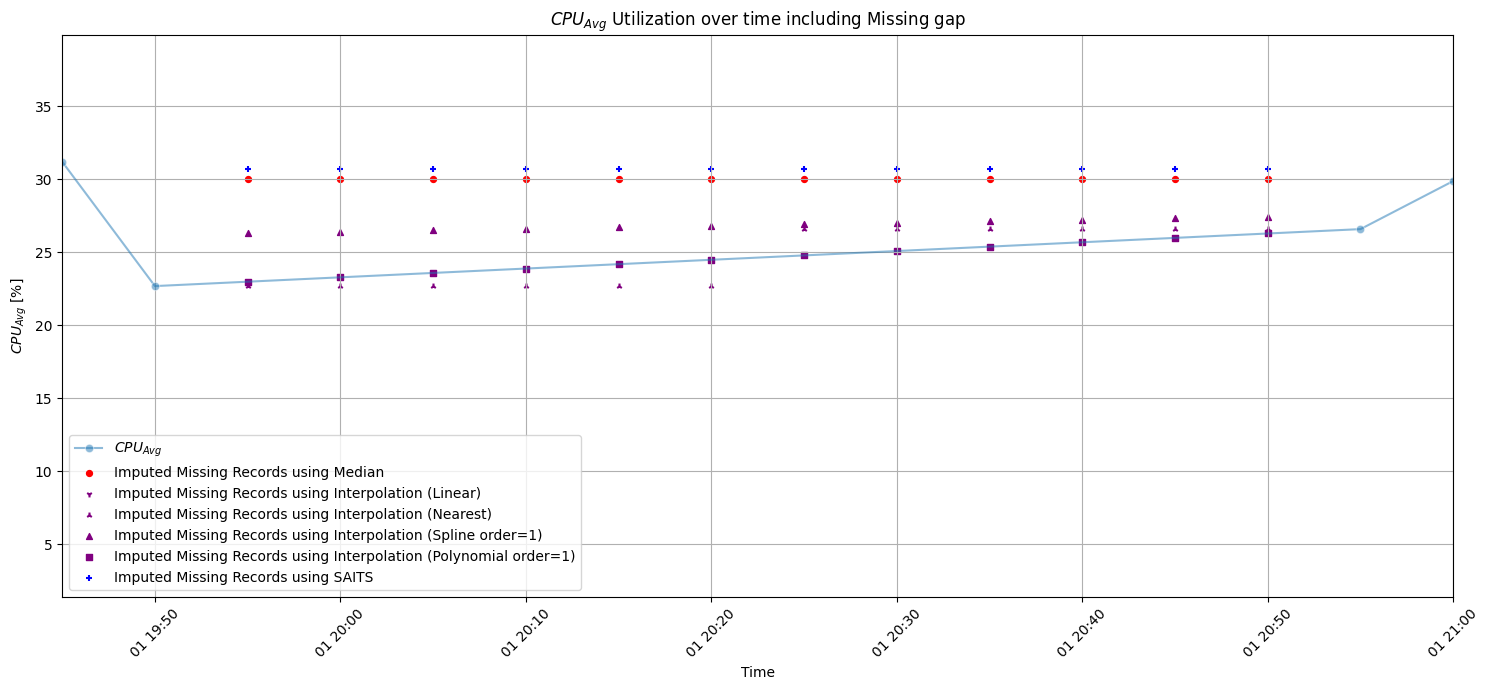

In [83]:
# Filter the records that have been added
imputed_NaN_values_records1 = df_final1[df_final1['fixed_records'] == 1]
imputed_NaN_values_records2 = df_final2[df_final2['fixed_records'] == 1]
imputed_NaN_values_records3 = df_final3[df_final3['fixed_records'] == 1]
imputed_NaN_values_records4 = df_final4[df_final4['fixed_records'] == 1]
imputed_NaN_values_records5 = df_final5[df_final5['fixed_records'] == 1]
imputed_NaN_values_records6 = df_final6[df_final6['fixed_records'] == 1]

# Define the x-axis limits
start_time = pd.to_datetime("2019-01-01 19:45:00")
end_time   = pd.to_datetime("2019-01-01 21:00:00")

# Plot the original data with missing records highlighted and annotated, with x-axis limits
plt.figure(figsize=(15, 7))
sns.lineplot(data=data, x='timestamp', y='avgcpu', label='$CPU_{Avg}$', marker='o', alpha=0.5)
plt.scatter(imputed_NaN_values_records1.index, imputed_NaN_values_records1['avgcpu'], color='r', label='Imputed Missing Records using Median', marker='o', s=18)
plt.scatter(imputed_NaN_values_records2.index, imputed_NaN_values_records2['avgcpu'], color='#800080', label='Imputed Missing Records using Interpolation (Linear)', marker='1', s=18)
plt.scatter(imputed_NaN_values_records3.index, imputed_NaN_values_records3['avgcpu'], color='#800080', label='Imputed Missing Records using Interpolation (Nearest)', marker='2', s=18)
plt.scatter(imputed_NaN_values_records4.index, imputed_NaN_values_records4['avgcpu'], color='#800080', label='Imputed Missing Records using Interpolation (Spline order=1)', marker='^', s=18)
plt.scatter(imputed_NaN_values_records5.index, imputed_NaN_values_records5['avgcpu'], color='#800080', label='Imputed Missing Records using Interpolation (Polynomial order=1)', marker='s', s=18)
plt.scatter(imputed_NaN_values_records6.index, imputed_NaN_values_records6['avgcpu'], color='b', label='Imputed Missing Records using SAITS', marker='+', s=18)

plt.title('$CPU_{Avg}$ Utilization over time including Missing gap')
plt.xlabel('Time')
plt.ylabel('$CPU_{Avg}$ [%]')
plt.legend()
plt.xticks(rotation=45)
plt.xlim(start_time, end_time) # Set x-axis limits
plt.tight_layout()
plt.grid()
plt.show()

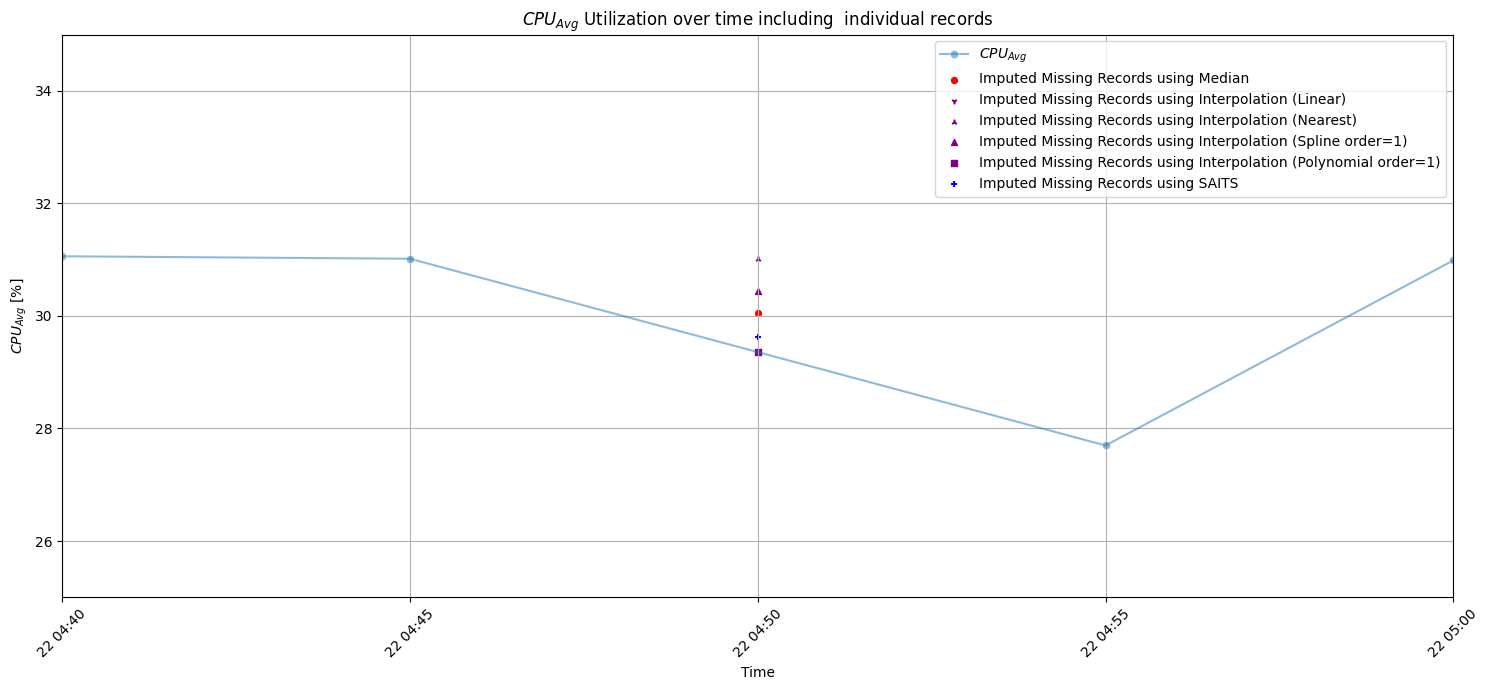

In [82]:
# Define the x and y-axis limits
start_time = pd.to_datetime("2019-01-22 04:40:00")
end_time   = pd.to_datetime("2019-01-22 05:00:00")
y_min = 25
y_max = 35

# Plot the original data with missing records highlighted and annotated, with x and y-axis limits
plt.figure(figsize=(15, 7))
sns.lineplot(data=data, x='timestamp', y='avgcpu', label='$CPU_{Avg}$', marker='o', alpha=0.5)
plt.scatter(imputed_NaN_values_records1.index, imputed_NaN_values_records1['avgcpu'], color='r', label='Imputed Missing Records using Median', marker='o', s=18)
plt.scatter(imputed_NaN_values_records2.index, imputed_NaN_values_records2['avgcpu'], color='#800080', label='Imputed Missing Records using Interpolation (Linear)', marker='1', s=18)
plt.scatter(imputed_NaN_values_records3.index, imputed_NaN_values_records3['avgcpu'], color='#800080', label='Imputed Missing Records using Interpolation (Nearest)', marker='2', s=18)
plt.scatter(imputed_NaN_values_records4.index, imputed_NaN_values_records4['avgcpu'], color='#800080', label='Imputed Missing Records using Interpolation (Spline order=1)', marker='^', s=18)
plt.scatter(imputed_NaN_values_records5.index, imputed_NaN_values_records5['avgcpu'], color='#800080', label='Imputed Missing Records using Interpolation (Polynomial order=1)', marker='s', s=18)
plt.scatter(imputed_NaN_values_records6.index, imputed_NaN_values_records6['avgcpu'], color='b', label='Imputed Missing Records using SAITS', marker='+', s=18)

plt.title('$CPU_{Avg}$ Utilization over time including  individual records')
plt.xlabel('Time')
plt.ylabel('$CPU_{Avg}$ [%]')
plt.legend()
plt.xticks(rotation=45)
plt.xlim(start_time, end_time)  # Set x-axis limits
plt.ylim(y_min, y_max)          # Set y-axis limits
plt.tight_layout()
plt.grid()
plt.show()

##Logging | Notebook END Time

In [76]:
NOTEBOOK_END_TIME_UC0   = time.time()  #now.strftime("%Y-%m-%d %H:%M:%S") #time.time_ns()    #time.time()
#NOTEBOOK_EXECUTION_TIME_UC8 = (NOTEBOOK_END_TIME_UC11 - NOTEBOOK_START_TIME_UC11 ) / 1e9d

time_delta_total_seconds = (NOTEBOOK_END_TIME_UC0 - NOTEBOOK_START_TIME_UC0)
NOTEBOOK_EXECUTION_TIME_UC0 = time_delta_total_seconds/60

print(f"================[INFO]_${zeit}=======================")
print(f"| Notebook was successfully executed in {NOTEBOOK_EXECUTION_TIME_UC0} minutes | \n ------------------------------------------------------------------ ")

================[INFO]_$2025-03-17 20:41:57=======================
| Notebook was successfully executed in 11.791635711987814 minutes | 
 ------------------------------------------------------------------ 
